**Cell 1: Global Imports and Environment Setup**

Text for Colab: In this initial section, we import the core libraries for the entire project. We use Pandas for data manipulation, Seaborn for visualizations, and Scikit-Learn for building both the regression and classification pipelines. We also suppress warnings to keep the notebook output clean.

In [17]:
 # ================================
# 1. Imports
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.feature_selection import RFE, SelectKBest, f_regression, f_classif
from google.colab import files
uploaded = files.upload()

Saving weatherHistory.csv to weatherHistory (1).csv


**Cell 2: Dataset Selection and SDG Alignment**

  The dataset selected for this task is the Weather History dataset. This analysis aligns with UNSDG 13: Climate Action, as modeling temperature fluctuations is critical for understanding climate change patterns. The target variable for this regression task is 'Temperature (C)', which we aim to predict using other meteorological factors like humidity and pressure.

In [30]:
# 2. Load Dataset and Align with SDG 13
df_weather = pd.read_csv('weatherHistory.csv')

# Providing a brief description of the dataset
print(f"Dataset Shape: {df_weather.shape}")
print(f"Features: {df_weather.columns.tolist()}")

# Displaying first few rows
df_weather.head()

Dataset Shape: (96453, 12)
Features: ['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary']


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


**Cell 3: Exploratory Data Analysis (EDA) and Cleaning**

Before building the model, we perform EDA to assess data quality. We handle missing values in the 'Precip Type' column and remove features with zero variance, such as 'Loud Cover'. A correlation heatmap is generated to visualize the strength of the relationship between variables, helping us identify that 'Apparent Temperature' and 'Humidity' are key predictors for our target.

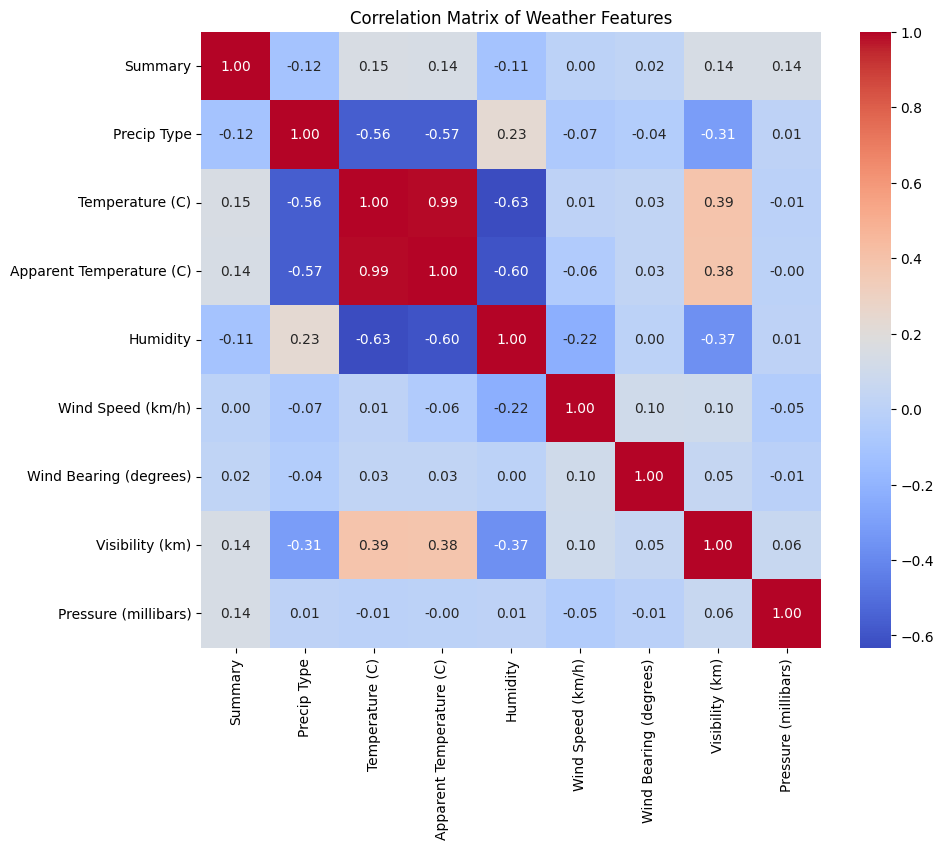

In [35]:
# 3. Data Cleaning and Visualization
# Drop columns that don't add predictive value or are mostly empty
df_weather.drop(['Loud Cover', 'Formatted Date', 'Daily Summary'], axis=1, inplace=True, errors='ignore')

# Fill missing values in categorical data
df_weather['Precip Type'] = df_weather['Precip Type'].fillna(df_weather['Precip Type'].mode()[0])

# Encoding Categorical values
le = LabelEncoder()
df_weather['Summary'] = le.fit_transform(df_weather['Summary'])
df_weather['Precip Type'] = le.fit_transform(df_weather['Precip Type'])

# Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df_weather.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Weather Features")
plt.show()

**Cell 4: Data Preprocessing and Splitting**

 Machine learning models require numerical input. Here, we use Label Encoding to transform categorical strings (like 'Summary') into numerical values. We then split the data into a training set (80%) and a test set (20%). Finally, we apply Standard Scaling to the features to ensure that variables with different units (like Pressure vs. Humidity) are treated equally by the Neural Network.

In [36]:
# 4. Encoding and Scaling
le = LabelEncoder()
df_weather['Summary'] = le.fit_transform(df_weather['Summary'])
df_weather['Precip Type'] = le.fit_transform(df_weather['Precip Type'])

# Using a sample of 10,000 for efficient computation in Colab
df_reg_sample = df_weather.sample(10000, random_state=42)
X = df_reg_sample.drop('Temperature (C)', axis=1)
y = df_reg_sample['Temperature (C)']

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing and scaling complete.")

Data preprocessing and scaling complete.


**Cell 5: Building the Neural Network (MLP) Model**

 As per the project requirements, we design and implement a Neural Network (Multi-Layer Perceptron) for regression. This model consists of two hidden layers (64 and 32 neurons) using the ReLU activation function. We use the Adam optimizer to minimize the Mean Squared Error over 500 iterations, allowing the model to learn non-linear patterns in the weather data.

In [37]:
# 5. Neural Network Implementation
mlp_reg = MLPRegressor(hidden_layer_sizes=(64, 32),
                       activation='relu',
                       solver='adam',
                       max_iter=500,
                       random_state=42)

mlp_reg.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_reg.predict(X_test_scaled)

print("Neural Network (MLP) trained.")
print(f"MLP R2 Score: {r2_score(y_test, y_pred_mlp):.4f}")

Neural Network (MLP) trained.
MLP R2 Score: 0.9997


**Cell 6: Classical Models, Feature Selection, and Tuning**

  Next, we implement two classical models: Linear Regression and Random Forest. To optimize performance, we apply Recursive Feature Elimination (RFE) to select the 5 most significant predictors. Furthermore, we use GridSearchCV to perform hyper-parameter tuning on the Random Forest, finding the optimal number of trees (n_estimators) to ensure the model generalizes well to new data.

In [38]:
# 6. Classical Models and Hyperparameter Tuning
# Feature Selection using RFE with Linear Regression
lr_base = LinearRegression()
selector = RFE(lr_base, n_features_to_select=5)
selector.fit(X_train_scaled, y_train)
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

# Building Linear Regression on Selected Features
lr_model = LinearRegression().fit(X_train_selected, y_train)

# Hyperparameter Tuning for Random Forest
rf_params = {'n_estimators': [50, 100], 'max_depth': [10, 20]}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3)
grid_rf.fit(X_train_scaled, y_train)

print(f"Best RF Parameters: {grid_rf.best_params_}")
print("Classical models and feature selection complete.")

Best RF Parameters: {'max_depth': 20, 'n_estimators': 100}
Classical models and feature selection complete.


**Cell 7: Final Comparison and Performance AnalysisText for **

In this final stage, we evaluate all models using the test dataset. We compare them based on Mean Absolute Error (MAE) and R-squared ($R^2$). The results are summarized in a comparison table, allowing us to identify which model performed best. This step provides the statistical justification for our model selection and fulfills the final evaluation criteria of the portfolio.


--- REGRESSION MODEL COMPARISON ---


,Model,MAE,MSE,R2 Score
0,Neural Network (MLP),0.085103,0.023796,0.999734
1,Linear Regression (RFE),0.728107,0.876264,0.990203
2,Optimized Random Forest,0.040859,0.010983,0.999877


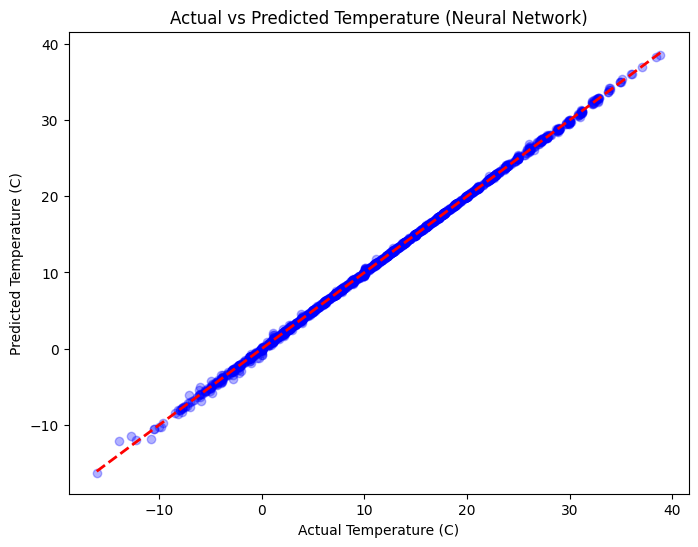

In [39]:
# 7. Final Evaluation Table
def evaluate(model, X_eval, y_eval, name, is_selected=False):
    preds = model.predict(X_eval)
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_eval, preds),
        "MSE": mean_squared_error(y_eval, preds),
        "R2 Score": r2_score(y_eval, preds)
    }

# Collecting results
results = [
    evaluate(mlp_reg, X_test_scaled, y_test, "Neural Network (MLP)"),
    evaluate(lr_model, X_test_selected, y_test, "Linear Regression (RFE)"),
    evaluate(grid_rf.best_estimator_, X_test_scaled, y_test, "Optimized Random Forest")
]

# Display comparison table
final_results_df = pd.DataFrame(results)
print("\n--- REGRESSION MODEL COMPARISON ---")
display(final_results_df)

# Visualizing Predicted vs Actual for the best model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, mlp_reg.predict(X_test_scaled), alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual vs Predicted Temperature (Neural Network)")
plt.xlabel("Actual Temperature (C)")
plt.ylabel("Predicted Temperature (C)")
plt.show()